In [1]:
import pandas as pd

gdp = pd.read_csv("GDP of Pakistan.csv")
growth = pd.read_csv("GDP Growth of Pakistan - Sheet1 (1).csv")

print("GDP shape:", gdp.shape)
print("Growth shape:", growth.shape)

display(gdp.head())
display(growth.head())


GDP shape: (266, 68)
Growth shape: (64, 2)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.790850e+09,2.962907e+09,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.558906e+09,3.103184e+09,3.544708e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.121696e+10,2.230747e+10,2.370247e+10,2.577938e+10,2.804954e+10,3.037491e+10,...,9.796900e+11,8.992960e+11,8.298300e+11,9.401050e+11,1.012720e+12,1.006530e+12,9.290740e+11,1.086770e+12,1.183960e+12,1.236160e+12
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426650e+10,1.450216e+10,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.188413e+10,1.268566e+10,1.360683e+10,1.443998e+10,1.576911e+10,1.693448e+10,...,8.945850e+11,7.693670e+11,6.921810e+11,6.857500e+11,7.681900e+11,8.239340e+11,7.871470e+11,8.459930e+11,8.771410e+11,7.965860e+11
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.359670e+11,9.049642e+10,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.044000e+11,8.472296e+10


,World Development Indicator,Unnamed: 1
0,Country Name,Pakistan
1,Indicator Name,GDP growth (annual %)
2,1960,NaN
3,1961,5.987346419
4,1962,4.482858627


In [2]:
print("GDP columns:", list(gdp.columns))
print("Growth columns:", list(growth.columns))


GDP columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
Growth columns: ['World Development Indicator', 'Unnamed: 1']


In [3]:
# Try to auto-detect Year column
def find_year_col(df):
    for c in df.columns:
        if str(c).lower() in ["year", "years", "date"]:
            return c
    return df.columns[0]  # fallback

year_gdp = find_year_col(gdp)
year_growth = find_year_col(growth)

# Auto-detect value column (take the last column usually)
val_gdp = gdp.columns[-1]
val_growth = growth.columns[-1]

# Convert to numeric
gdp[year_gdp] = pd.to_numeric(gdp[year_gdp], errors="coerce")
gdp[val_gdp] = pd.to_numeric(gdp[val_gdp], errors="coerce")

growth[year_growth] = pd.to_numeric(growth[year_growth], errors="coerce")
growth[val_growth] = pd.to_numeric(growth[val_growth], errors="coerce")

# Drop empty rows
gdp = gdp.dropna(subset=[year_gdp, val_gdp]).sort_values(year_gdp)
growth = growth.dropna(subset=[year_growth, val_growth]).sort_values(year_growth)

gdp.head(), growth.head()


(Empty DataFrame
 Columns: [Country Name, Country Code, Indicator Name, Indicator Code, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
 Index: []
 
 [0 rows x 68 columns],
    World Development Indicator  Unnamed: 1
 3                       1961.0    5.987346
 4                       1962.0    4.482859
 5                       1963.0    8.688832
 6                       1964.0    7.569757
 7                       1965.0   10.419366)

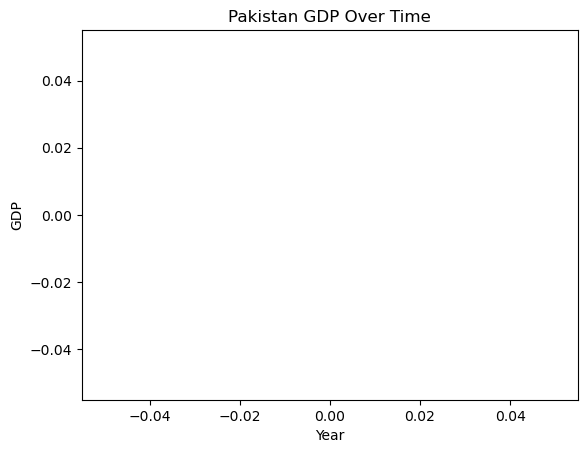

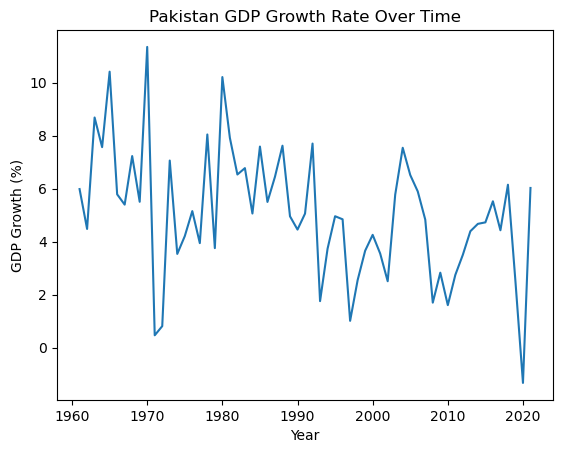

In [4]:
import matplotlib.pyplot as plt

# GDP line chart
plt.figure()
plt.plot(gdp[year_gdp], gdp[val_gdp])
plt.title("Pakistan GDP Over Time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()

# GDP growth line chart
plt.figure()
plt.plot(growth[year_growth], growth[val_growth])
plt.title("Pakistan GDP Growth Rate Over Time")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()


In [5]:
best = growth.loc[growth[val_growth].idxmax(), [year_growth, val_growth]]
worst = growth.loc[growth[val_growth].idxmin(), [year_growth, val_growth]]
best, worst


(World Development Indicator    1970.000000
 Unnamed: 1                       11.353462
 Name: 12, dtype: float64,
 World Development Indicator    2020.00000
 Unnamed: 1                       -1.32952
 Name: 62, dtype: float64)

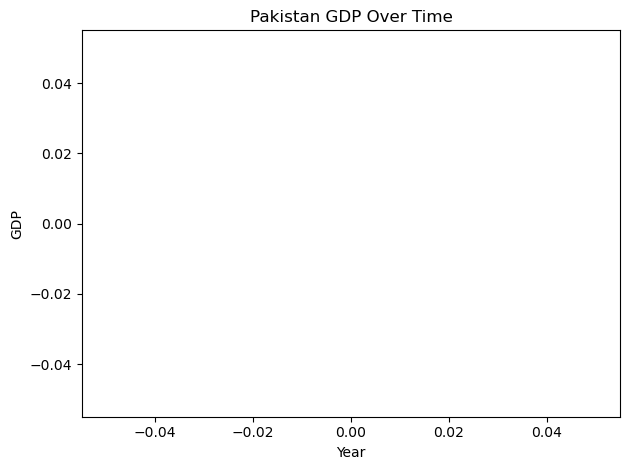

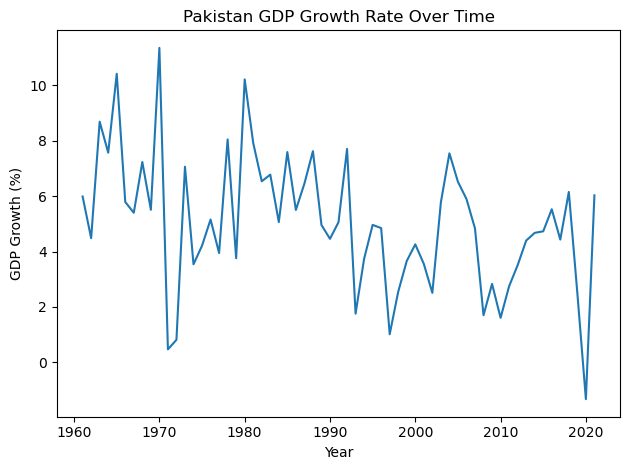

In [6]:
plt.figure()
plt.plot(gdp[year_gdp], gdp[val_gdp])
plt.title("Pakistan GDP Over Time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.tight_layout()
plt.savefig("pakistan_gdp.png", dpi=200)
plt.show()

plt.figure()
plt.plot(growth[year_growth], growth[val_growth])
plt.title("Pakistan GDP Growth Rate Over Time")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig("pakistan_gdp_growth.png", dpi=200)
plt.show()


In [7]:
print(list(gdp.columns))
print(list(growth.columns))


['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
['World Development Indicator', 'Unnamed: 1']
